In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, roc_auc_score, precision_score, accuracy_score, f1_score

In [2]:
df_nondiab = pd.read_csv("nondiabetic_merged_filled.csv")
df_nondiab["diabetes_status"] = 0
df_nondiab.drop(columns=["Respondent_ID"], inplace=True)
df_nondiab.rename(columns={"Sex_num": "Gender"}, inplace=True)
df_nondiab.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gender                 378 non-null    int64  
 1   alcohol_ord            378 non-null    int64  
 2   Age                    378 non-null    int64  
 3   Height_cm              377 non-null    float64
 4   Weight_kg              377 non-null    float64
 5   BMI                    376 non-null    float64
 6   Course                 355 non-null    object 
 7   Year Level             355 non-null    object 
 8   fruit_freq_ord         378 non-null    int64  
 9   veg_freq_ord           378 non-null    int64  
 10  sweets_freq_ord        378 non-null    int64  
 11  fastfood_freq_ord      378 non-null    int64  
 12  processed_freq_ord     378 non-null    int64  
 13  sweetdrink_freq_ord    378 non-null    int64  
 14  fried_food_freq_ord    378 non-null    int64  
 15  lose_w

In [3]:
df_diab = pd.read_csv("diab_merge_final.csv")
df_diab["diabetes_status"] = 1
df_diab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    68 non-null     int64  
 1   Gender                 66 non-null     float64
 2   Height_cm              68 non-null     float64
 3   Weight_kg              68 non-null     float64
 4   BMI                    68 non-null     float64
 5   fruit_freq_ord         67 non-null     float64
 6   veg_freq_ord           67 non-null     float64
 7   sweets_freq_ord        66 non-null     float64
 8   fastfood_freq_ord      67 non-null     float64
 9   processed_freq_ord     66 non-null     float64
 10  sweetdrink_freq_ord    67 non-null     float64
 11  fried_food_freq_ord    65 non-null     float64
 12  lose_weight_ord        66 non-null     float64
 13  exercise_yes_ord       66 non-null     float64
 14  exercise_freq_ord      64 non-null     float64
 15  exercise

In [4]:
merged_df = pd.concat([df_nondiab, df_diab], ignore_index=True)

merged_df.drop(columns=["BMI", "child_diab_ord", "Course", "Year Level", "Height_cm", "Weight_kg", "Age", "Gender", "alcohol_ord.1", "concern_level_ord"], inplace=True)
merged_df.info()
merged_df["diabetes_status"].value_counts()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 446 entries, 0 to 445
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   alcohol_ord            443 non-null    float64
 1   fruit_freq_ord         445 non-null    float64
 2   veg_freq_ord           445 non-null    float64
 3   sweets_freq_ord        444 non-null    float64
 4   fastfood_freq_ord      445 non-null    float64
 5   processed_freq_ord     444 non-null    float64
 6   sweetdrink_freq_ord    445 non-null    float64
 7   fried_food_freq_ord    443 non-null    float64
 8   lose_weight_ord        443 non-null    float64
 9   exercise_yes_ord       444 non-null    float64
 10  exercise_freq_ord      442 non-null    float64
 11  exercise_duration_ord  445 non-null    float64
 12  sedentary_hours_ord    440 non-null    float64
 13  activity_level_ord     443 non-null    float64
 14  transpo_ord            378 non-null    float64
 15  sleep_

diabetes_status
0    378
1     68
Name: count, dtype: int64

In [5]:


merged_df.fillna(merged_df.median(numeric_only=True), inplace=True)
merged_df.info()
merged_df["diabetes_status"].value_counts()
merged_df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 446 entries, 0 to 445
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   alcohol_ord            446 non-null    float64
 1   fruit_freq_ord         446 non-null    float64
 2   veg_freq_ord           446 non-null    float64
 3   sweets_freq_ord        446 non-null    float64
 4   fastfood_freq_ord      446 non-null    float64
 5   processed_freq_ord     446 non-null    float64
 6   sweetdrink_freq_ord    446 non-null    float64
 7   fried_food_freq_ord    446 non-null    float64
 8   lose_weight_ord        446 non-null    float64
 9   exercise_yes_ord       446 non-null    float64
 10  exercise_freq_ord      446 non-null    float64
 11  exercise_duration_ord  446 non-null    float64
 12  sedentary_hours_ord    446 non-null    float64
 13  activity_level_ord     446 non-null    float64
 14  transpo_ord            446 non-null    float64
 15  sleep_

Index(['alcohol_ord', 'fruit_freq_ord', 'veg_freq_ord', 'sweets_freq_ord',
       'fastfood_freq_ord', 'processed_freq_ord', 'sweetdrink_freq_ord',
       'fried_food_freq_ord', 'lose_weight_ord', 'exercise_yes_ord',
       'exercise_freq_ord', 'exercise_duration_ord', 'sedentary_hours_ord',
       'activity_level_ord', 'transpo_ord', 'sleep_ord', 'smoking_ord',
       'father_diab_ord', 'mother_diab_ord', 'sister_diab_ord',
       'brother_diab_ord', 'extended_diab_ord', 'diabetes_status'],
      dtype='object')

In [ ]:
X = merged_df.drop(columns=["diabetes_status"])
y = merged_df["diabetes_status"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy={0: 700, 1: 400},
    random_state=42
)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train, y_train
)

import pandas as pd

X_resampled_df = pd.DataFrame(
    X_train_resampled,
    columns=X.columns
)
y_resampled_df = pd.Series(
    y_train_resampled,
    name="diabetes_status"
)
resampled_df = pd.concat(
    [X_resampled_df, y_resampled_df],
    axis=1
)
resampled_df["diabetes_status"].value_counts()
resampled_df.to_excel(
    "smote_resampled_training_data2.xlsx",
    index=False
)


In [13]:
import pandas as pd

# Load the Excel file
df = pd.read_excel('smote_resampled_training_data2.xlsx')

# Convert all numeric columns to integer
for col in df.columns:
    if df[col].dtype in ['float64', 'float32']:
        df[col] = df[col].round().astype(int)
    elif df[col].dtype == 'float':
        df[col] = df[col].round().astype(int)

# Save to a new Excel file
df.to_excel('smote_resampled_training_data2_integer.xlsx', index=False)



In [2]:
lifestyle_data = pd.read_excel('resampled_final_lifestyle_data.xlsx')

X = lifestyle_data.drop(columns=["diabetes_status"])
y = lifestyle_data["diabetes_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
lifestyle_data["diabetes_status"].value_counts()
import matplotlib.pyplot as plt

# Get descriptive statistics
lifestyle_data.describe()




,alcohol_ord,fruit_freq_ord,veg_freq_ord,sweets_freq_ord,fastfood_freq_ord,processed_freq_ord,sweetdrink_freq_ord,fried_food_freq_ord,lose_weight_ord,exercise_yes_ord,...,activity_level_ord,transpo_ord,sleep_ord,smoking_ord,father_diab_ord,mother_diab_ord,sister_diab_ord,brother_diab_ord,extended_diab_ord,diabetes_status
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,1.854545,2.919091,3.732727,3.450909,2.855455,3.106364,2.955455,3.657273,2.352727,1.557273,...,2.492727,2.548182,2.577273,1.370000,1.305455,1.453636,1.199091,1.150909,2.108182,0.363636
std,0.990734,0.817127,0.995633,1.012366,0.915948,1.007052,1.204638,0.951887,0.856991,0.496935,...,0.900380,0.799480,0.698648,0.860841,0.608827,0.786970,0.476375,0.398985,0.742648,0.481264
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,2.000000,3.000000,3.000000,2.000000,2.000000,2.000000,3.000000,2.000000,1.000000,...,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000
50%,1.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,2.000000,...,2.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000
75%,3.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,3.000000,2.000000,...,3.000000,3.000000,3.000000,1.000000,1.000000,2.000000,1.000000,1.000000,3.000000,1.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,2.000000,...,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,4.000000,3.000000,1.000000


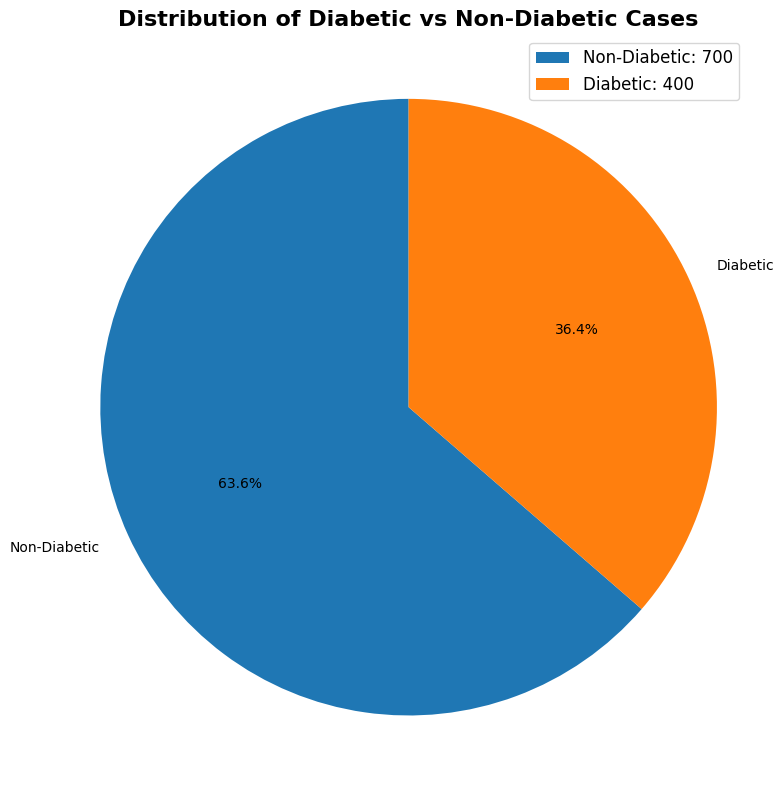

Diabetes Status Distribution:
diabetes_status
0    700
1    400
Name: count, dtype: int64

Total samples: 1100
Diabetic percentage: 36.36%
Non-diabetic percentage: 63.64%


In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you've already loaded the data
# lifestyle_data = pd.read_excel('resampled_final_lifestyle_data.xlsx')

# Count diabetic and non-diabetic cases
diabetes_counts = lifestyle_data["diabetes_status"].value_counts()

# Create labels and values
labels = ['Non-Diabetic', 'Diabetic'] if 0 in diabetes_counts.index else ['Diabetic', 'Non-Diabetic']
sizes = diabetes_counts.values


# Create pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Diabetic vs Non-Diabetic Cases', fontsize=16, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

# Add count numbers on the pie chart or in legend
plt.legend([f'{label}: {size}' for label, size in zip(labels, sizes)], 
           loc='best', fontsize=12)

plt.tight_layout()
plt.show()

# Print the counts
print("Diabetes Status Distribution:")
print(diabetes_counts)
print(f"\nTotal samples: {len(lifestyle_data)}")
print(f"Diabetic percentage: {(diabetes_counts.get(1, 0) / len(lifestyle_data)) * 100:.2f}%")
print(f"Non-diabetic percentage: {(diabetes_counts.get(0, 0) / len(lifestyle_data)) * 100:.2f}%")

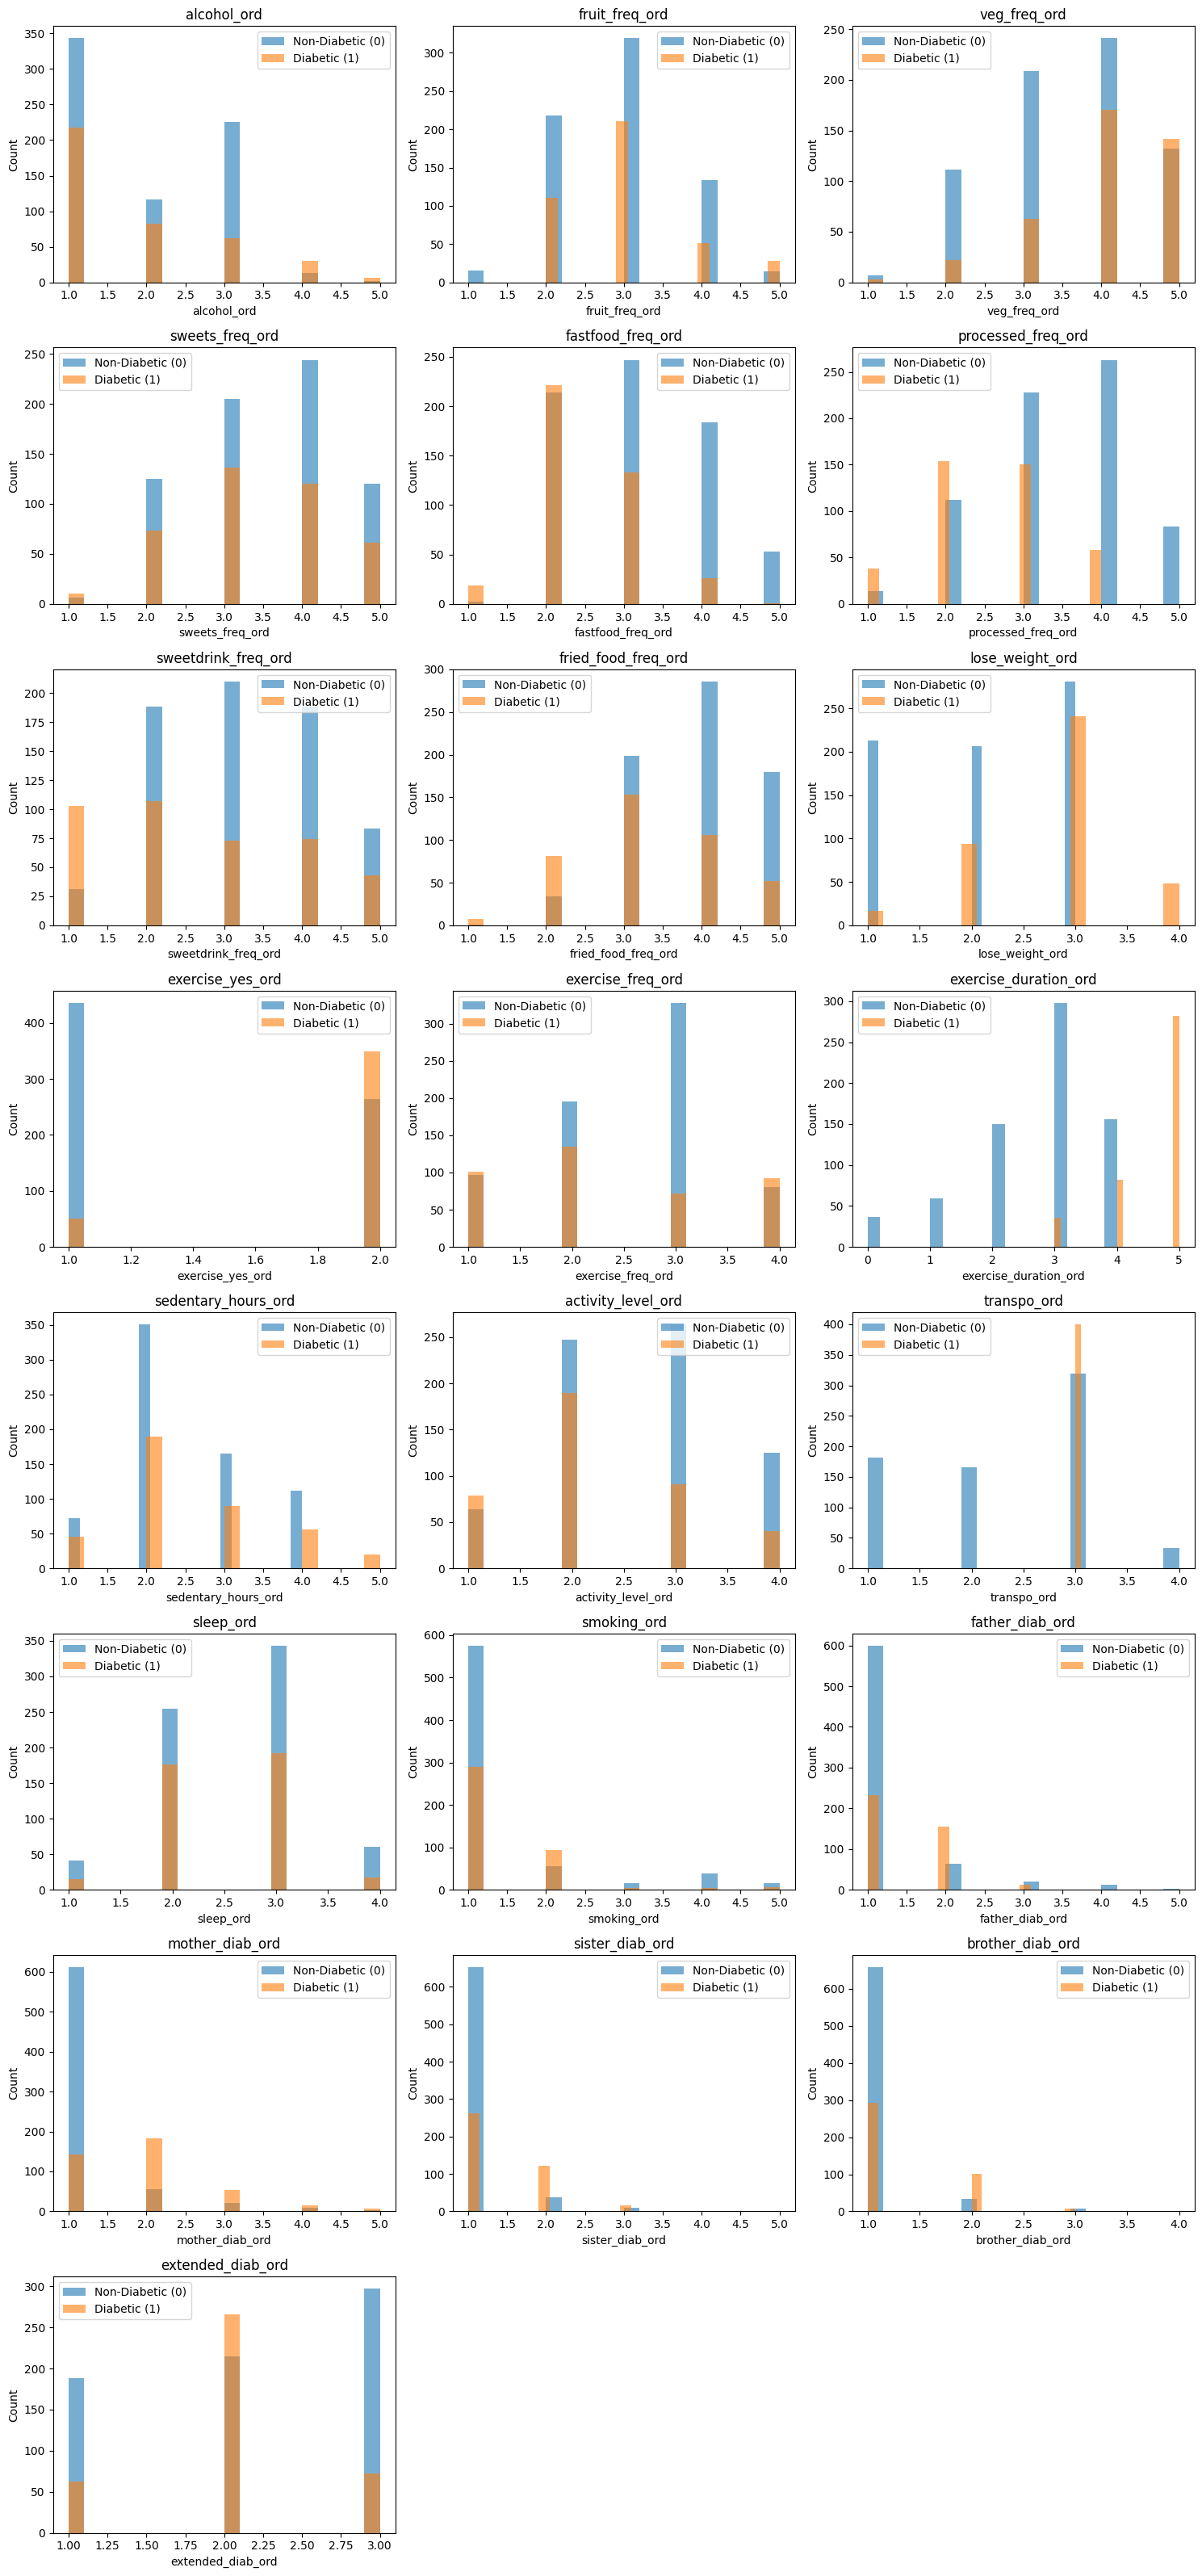

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
lifestyle_data = pd.read_excel('resampled_final_lifestyle_data.xlsx')

target = "diabetes_status"

# Use only numeric features (exclude target)
features = lifestyle_data.drop(columns=[target]) \
                          .select_dtypes(include=['int64', 'float64']) \
                          .columns

# Grid layout
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]

    lifestyle_data[lifestyle_data[target] == 0][col].plot(
        kind="hist",
        bins=20,
        alpha=0.6,
        label="Non-Diabetic (0)",
        ax=ax
    )

    lifestyle_data[lifestyle_data[target] == 1][col].plot(
        kind="hist",
        bins=20,
        alpha=0.6,
        label="Diabetic (1)",
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend()

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("lifestyle_feature_distributions_diabetes.png", dpi=300)
plt.show()


In [3]:
models = {
    "Logistic Regression": LogisticRegression(
    C=0.1,              # ← stronger regularization
    penalty="l2",
    max_iter=1000
),
    "Random Forest": RandomForestClassifier(max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [4]:
numeric_features = [ 'sweets_freq_ord', 'fruit_freq_ord', 'veg_freq_ord', 'fastfood_freq_ord',
    'processed_freq_ord', 'sweetdrink_freq_ord', 'fried_food_freq_ord',
    'lose_weight_ord', 'exercise_yes_ord', 'exercise_freq_ord', 'exercise_duration_ord'
,'sedentary_hours_ord',"activity_level_ord", "transpo_ord", "sleep_ord", "alcohol_ord", "father_diab_ord", "mother_diab_ord", "sister_diab_ord", "brother_diab_ord","extended_diab_ord"]

over = SMOTE(sampling_strategy=0.8)
under = RandomUnderSampler()

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='passthrough'  # keep any non-numeric features if present
)

print(numeric_features)

['sweets_freq_ord', 'fruit_freq_ord', 'veg_freq_ord', 'fastfood_freq_ord', 'processed_freq_ord', 'sweetdrink_freq_ord', 'fried_food_freq_ord', 'lose_weight_ord', 'exercise_yes_ord', 'exercise_freq_ord', 'exercise_duration_ord', 'sedentary_hours_ord', 'activity_level_ord', 'transpo_ord', 'sleep_ord', 'alcohol_ord', 'father_diab_ord', 'mother_diab_ord', 'sister_diab_ord', 'brother_diab_ord', 'extended_diab_ord']


In [5]:
def train_and_evaluate_model_SMOTE(models, X_train, y_train, X_valid, y_valid):
    """
    Enhanced version that returns model performance for comparison
    """
    results = {}

    for name, model in models.items():
        print(f"\n🔹 Training {name}...")

        pipe = ImbPipeline([
            ('preprocess', preprocessor),
            ('over', over),
            ('under', under),
            ('model', model)
        ])

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_valid)
        y_proba = pipe.predict_proba(X_valid)[:, 1]

        # Calculate multiple metrics
        roc_auc = roc_auc_score(y_valid, y_proba)
        accuracy = accuracy_score(y_valid, y_pred)
        precision = precision_score(y_valid, y_pred, zero_division=0)
        recall = recall_score(y_valid, y_pred, zero_division=0)
        f1 = f1_score(y_valid, y_pred, zero_division=0)

        # Store results
        results[name] = {
            'model': pipe,
            'roc_auc': roc_auc,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'predictions': y_pred,
            'probabilities': y_proba
        }

        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_valid, y_pred, digits=2))

        from sklearn.model_selection import StratifiedKFold, cross_val_score

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        scores = cross_val_score(
            pipe, X, y,
            scoring="f1",
            cv=cv
        )

        print(scores.mean(), scores.std())


        cm = confusion_matrix(y_valid, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title(f"{name} - Confusion Matrix")
        plt.show()

    return results

In [16]:
import matplotlib.pyplot as plt

def plot_accuracy_bar(results):
    model_names = []
    accuracy_scores = []

    for name, result in results.items():
        model_names.append(name)
        accuracy_scores.append(result["accuracy"])

    plt.figure(figsize=(8, 5))
    plt.bar(model_names, accuracy_scores)
    plt.xlabel("Models")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Comparison of Models")
    plt.ylim(0, 1)

    # display values on top of bars
    for i, v in enumerate(accuracy_scores):
        plt.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

    plt.show()


In [12]:
import matplotlib.pyplot as plt

def plot_roc_auc_bar(results):
    model_names = []
    roc_auc_scores = []

    for name, result in results.items():
        model_names.append(name)
        roc_auc_scores.append(result["roc_auc"])

    plt.figure(figsize=(8, 5))
    plt.bar(model_names, roc_auc_scores)
    plt.xlabel("Models")
    plt.ylabel("ROC–AUC Score")
    plt.title("ROC–AUC Comparison of Models")
    plt.ylim(0, 1)

    # show values on top of bars
    for i, v in enumerate(roc_auc_scores):
        plt.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

    plt.show()


In [11]:
best_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('over', over),
    ('under', under),
    ('model', LogisticRegression(
    C=0.1,              # ← stronger regularization
    penalty="l2",
    max_iter=1000
    ))
])

best_pipe.fit(X_train, y_train)
import joblib

joblib.dump(best_pipe, "lifestyle_pipe.pkl")
print("✅ Saved lifestyle_pipe.pkl successfully!")

✅ Saved lifestyle_pipe.pkl successfully!



🔹 Training Logistic Regression...
ROC-AUC: 0.9863
F1-Score: 0.9268
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       140
           1       0.90      0.95      0.93        80

    accuracy                           0.95       220
   macro avg       0.94      0.95      0.94       220
weighted avg       0.95      0.95      0.95       220

0.9631817831048064 0.010506651502710965


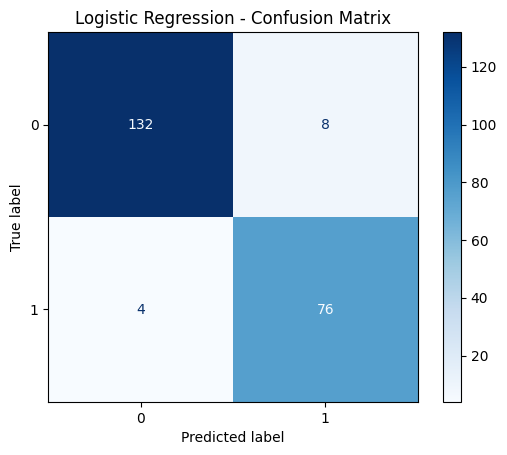


🔹 Training Random Forest...
ROC-AUC: 1.0000
F1-Score: 0.9938
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       140
           1       0.99      1.00      0.99        80

    accuracy                           1.00       220
   macro avg       0.99      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220

0.9924204823138245 0.007398463757481412


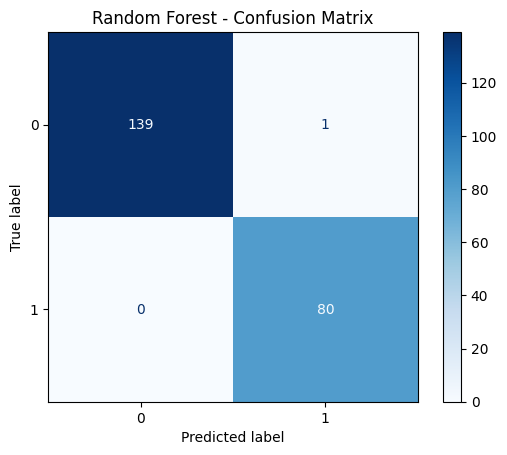


🔹 Training KNN...
ROC-AUC: 0.9842
F1-Score: 0.9639
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       140
           1       0.93      1.00      0.96        80

    accuracy                           0.97       220
   macro avg       0.97      0.98      0.97       220
weighted avg       0.97      0.97      0.97       220

0.9568932400632846 0.0130890918798381


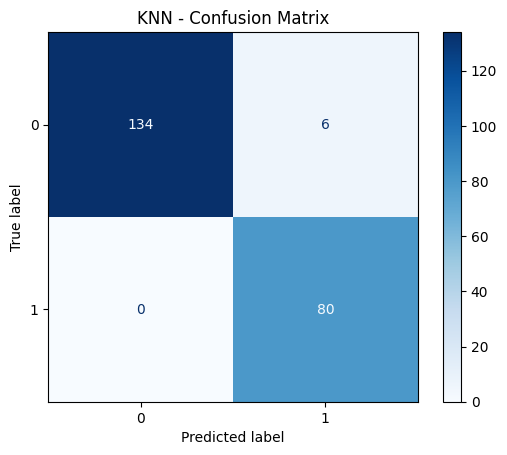


🔹 Training Naive Bayes...
ROC-AUC: 0.9819
F1-Score: 0.8122
              precision    recall  f1-score   support

           0       1.00      0.74      0.85       140
           1       0.68      1.00      0.81        80

    accuracy                           0.83       220
   macro avg       0.84      0.87      0.83       220
weighted avg       0.89      0.83      0.83       220

0.8415698548834145 0.009208961093372131


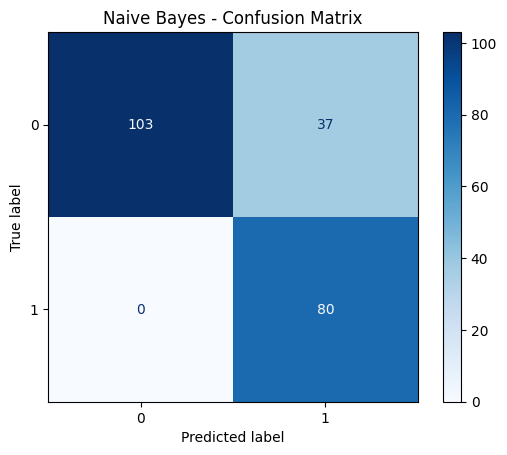


🔹 Training SVM...
ROC-AUC: 0.9988
F1-Score: 0.9750
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       140
           1       0.97      0.97      0.97        80

    accuracy                           0.98       220
   macro avg       0.98      0.98      0.98       220
weighted avg       0.98      0.98      0.98       220

0.9850452381791179 0.009410723483440025


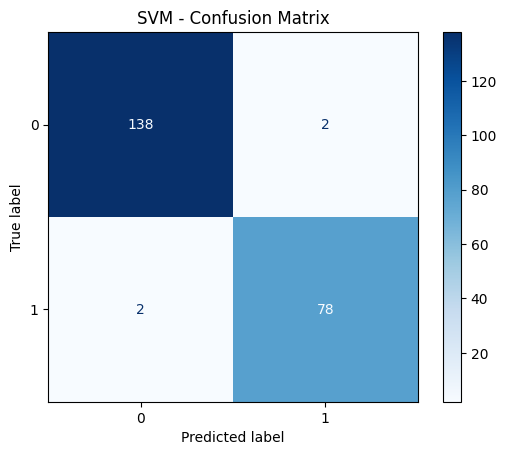


🔹 Training XGBoost...
ROC-AUC: 0.9986
F1-Score: 0.9689
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       140
           1       0.96      0.97      0.97        80

    accuracy                           0.98       220
   macro avg       0.97      0.98      0.98       220
weighted avg       0.98      0.98      0.98       220

0.984888337223563 0.011766536684932315


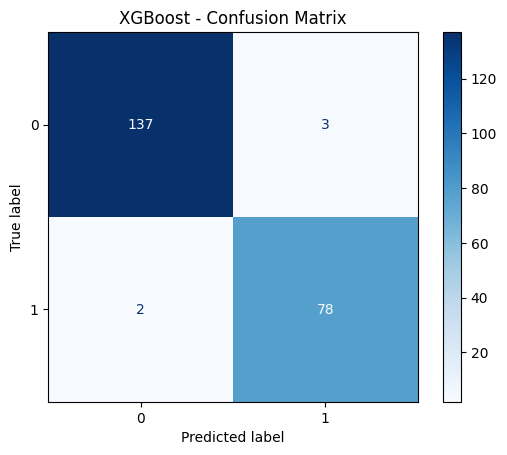


🏆 BEST MODEL: Random Forest with ROC-AUC: 1.0000


In [6]:
results = train_and_evaluate_model_SMOTE(models, X_train, y_train, X_test, y_test)

# Find best model
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']
print(f"\n🏆 BEST MODEL: {best_model_name} with ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")


FEATURE IMPORTANCE - LOGISTIC REGRESSION


AttributeError: 'Pipeline' object has no attribute 'coef_'

Dataset shape: (1100, 23)

Columns: ['alcohol_ord', 'fruit_freq_ord', 'veg_freq_ord', 'sweets_freq_ord', 'fastfood_freq_ord', 'processed_freq_ord', 'sweetdrink_freq_ord', 'fried_food_freq_ord', 'lose_weight_ord', 'exercise_yes_ord', 'exercise_freq_ord', 'exercise_duration_ord', 'sedentary_hours_ord', 'activity_level_ord', 'transpo_ord', 'sleep_ord', 'smoking_ord', 'father_diab_ord', 'mother_diab_ord', 'sister_diab_ord', 'brother_diab_ord', 'extended_diab_ord', 'diabetes_status']

First few rows:
   alcohol_ord  fruit_freq_ord  veg_freq_ord  sweets_freq_ord  \
0            1               3             4                2   
1            3               3             3                4   
2            2               2             5                2   
3            1               2             3                3   
4            2               3             5                1   

   fastfood_freq_ord  processed_freq_ord  sweetdrink_freq_ord  \
0                  2                   2   

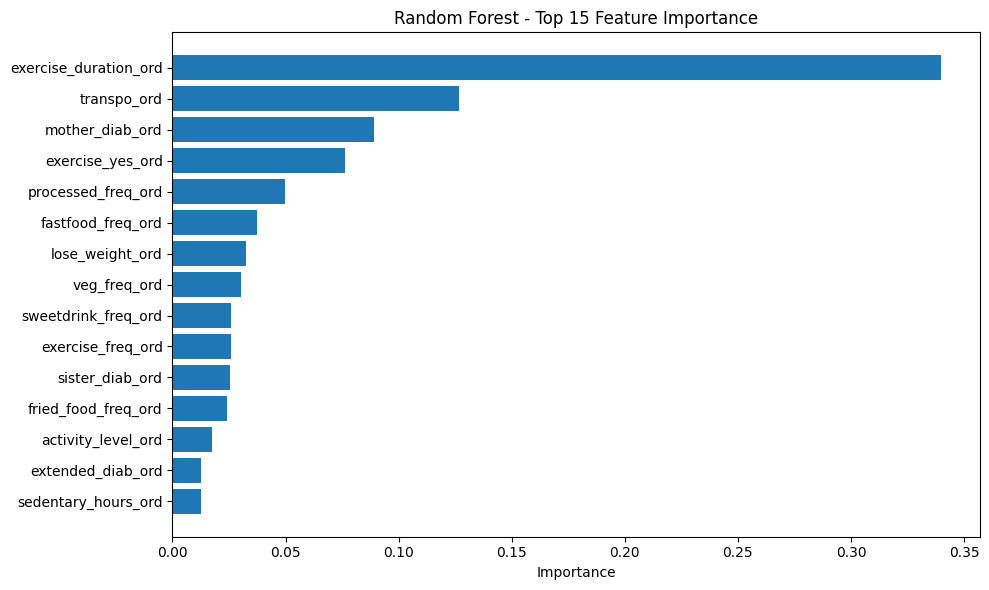


Gradient Boosting Feature Importance (Top 10):
              feature  importance
exercise_duration_ord    0.660867
          transpo_ord    0.125405
      mother_diab_ord    0.077665
   processed_freq_ord    0.037055
     exercise_yes_ord    0.020677
    fastfood_freq_ord    0.015144
      lose_weight_ord    0.013603
    exercise_freq_ord    0.011382
  sedentary_hours_ord    0.010201
         veg_freq_ord    0.006144


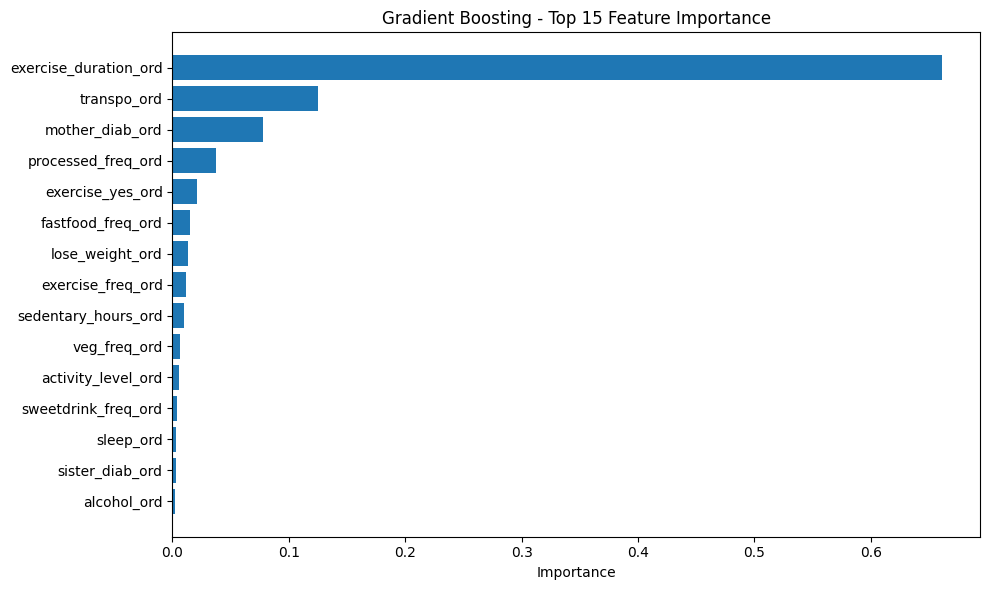


FINAL MODEL FOR DIABETES RISK PREDICTION
Selected best model: Random Forest

Performing hyperparameter tuning for Random Forest...
Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 1.0000

SAMPLE PREDICTIONS
Sample prediction for first data point:
  Actual diabetes status: No
  Predicted risk: 4.00%
  Risk category: Low Risk

Additional sample predictions:

Healthy lifestyle sample:
  Predicted risk: 24.00%
  Risk category: Medium Risk

Risky lifestyle sample:
  Predicted risk: 26.00%
  Risk category: Medium Risk

FINAL MODEL PERFORMANCE
Accuracy: 0.9955
Precision: 0.9877
Recall: 1.0000
F1-Score: 0.9938
ROC-AUC: 0.9997


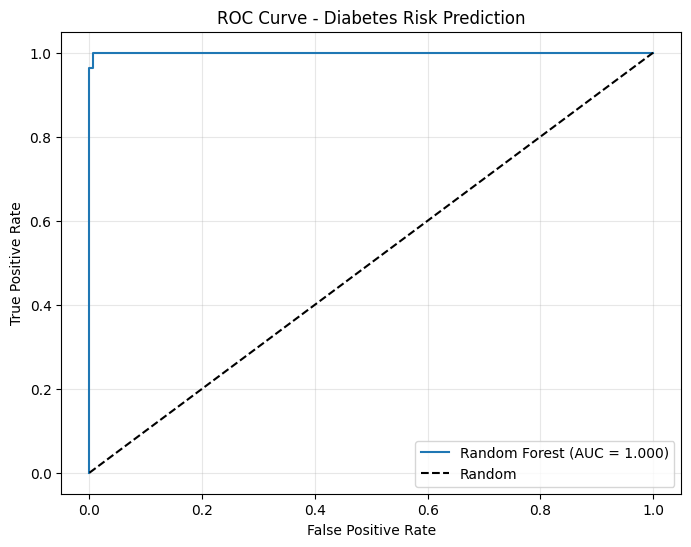


MODEL SAVED SUCCESSFULLY
Files saved in 'models' directory:
  - diabetes_risk_model.pkl (trained model)
  - scaler.pkl (feature scaler)
  - feature_names.pkl (feature names in correct order)

Logistic Regression Feature Importance:
              feature  importance
exercise_duration_ord    1.936760
          transpo_ord    1.227402
     exercise_yes_ord    0.697871
    fastfood_freq_ord    0.602352
      mother_diab_ord    0.498254
   processed_freq_ord    0.438388
      lose_weight_ord    0.436162
    exercise_freq_ord    0.429371
         veg_freq_ord    0.393954
     brother_diab_ord    0.336777
            sleep_ord    0.291942
  fried_food_freq_ord    0.287650
      sweets_freq_ord    0.258396
    extended_diab_ord    0.223522
   activity_level_ord    0.200632
          alcohol_ord    0.173761
      sister_diab_ord    0.173099
  sedentary_hours_ord    0.126616
          smoking_ord    0.102990
      father_diab_ord    0.075879
  sweetdrink_freq_ord    0.071802
       fruit_freq_o

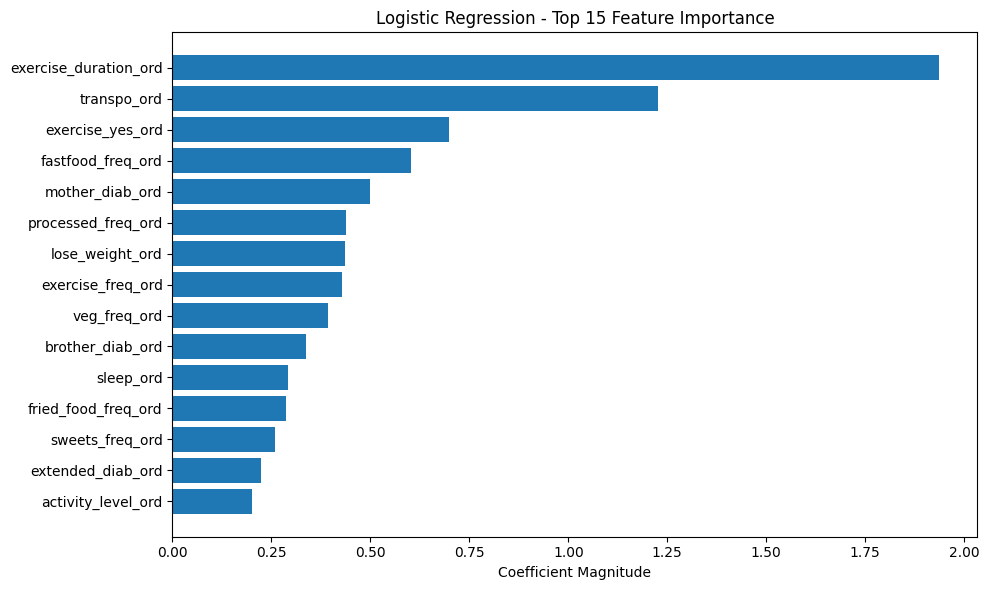

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Load the data
# Assuming the data is in a DataFrame named 'df' with the columns shown
# Let me recreate it from your provided data


df = pd.read_excel('resampled_final_lifestyle_data.xlsx')

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nDiabetes status distribution:")
print(df['diabetes_status'].value_counts())
print("\nProportion of diabetes cases:", df['diabetes_status'].mean() * 100, "%")

# Separate features and target
X = df.drop('diabetes_status', axis=1)
y = df['diabetes_status']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Diabetes prevalence in training: {y_train.mean():.2%}")
print(f"Diabetes prevalence in test: {y_test.mean():.2%}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(
    C=0.1,              # ← stronger regularization
    penalty="l2",
    max_iter=1000
),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}")
    print('='*50)
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    
    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Cross-validation ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

# Compare model performance
print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-Score': [results[m]['f1'] for m in results],
    'ROC-AUC': [results[m]['roc_auc'] for m in results],
    'CV ROC-AUC Mean': [results[m]['cv_mean'] for m in results],
    'CV ROC-AUC Std': [results[m]['cv_std'] for m in results]
})

print(comparison_df.sort_values('ROC-AUC', ascending=False).to_string(index=False))

# Feature importance for tree-based models
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

for name in ['Random Forest', 'Gradient Boosting']:
    if name in results:
        model = results[name]['model']
        feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print(f"\n{name} Feature Importance (Top 10):")
        print(feature_importance.head(10).to_string(index=False))
        
        # Plot feature importance
        plt.figure(figsize=(10, 6))
        top_features = feature_importance.head(15)
        plt.barh(range(len(top_features)), top_features['importance'])
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Importance')
        plt.title(f'{name} - Top 15 Feature Importance')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

# Train the best model on all data and create a prediction function
print("\n" + "="*80)
print("FINAL MODEL FOR DIABETES RISK PREDICTION")
print("="*80)

# Select best model based on ROC-AUC
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']
print(f"Selected best model: {best_model_name}")

# Retrain on full training data with optimal parameters
# Let's do hyperparameter tuning for the best model
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }
elif best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.1, 1, 10],
        'penalty': ['l1', 'l2']
    }
else:  # SVM
    param_grid = {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear']
    }

print(f"\nPerforming hyperparameter tuning for {best_model_name}...")
grid_search = GridSearchCV(
    best_model.__class__(**{k: v for k, v in best_model.get_params().items() 
                           if k in ['random_state']}),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

# Train final model on all training data
final_model = grid_search.best_estimator_
final_model.fit(X_train_scaled, y_train)

# Function to predict diabetes risk percentage
def predict_diabetes_risk(features_dict, model=final_model, scaler=scaler, feature_names=X.columns):
    """
    Predict diabetes risk percentage for a given set of features.
    
    Parameters:
    features_dict: Dictionary with feature names as keys and values
    model: Trained model
    scaler: Fitted scaler
    feature_names: List of feature names in correct order
    
    Returns:
    risk_percentage: Probability of diabetes (0-100%)
    risk_category: Low/Medium/High risk
    """
    # Create feature array in correct order
    features_array = []
    for feature in feature_names:
        if feature in features_dict:
            features_array.append(features_dict[feature])
        else:
            raise ValueError(f"Missing feature: {feature}")
    
    # Convert to numpy array and scale
    features_scaled = scaler.transform([features_array])
    
    # Predict probability
    probability = model.predict_proba(features_scaled)[0, 1]
    risk_percentage = probability * 100
    
    # Categorize risk
    if risk_percentage < 20:
        risk_category = "Low Risk"
    elif risk_percentage < 50:
        risk_category = "Medium Risk"
    else:
        risk_category = "High Risk"
    
    return risk_percentage, risk_category

# Test the prediction function with sample data
print("\n" + "="*80)
print("SAMPLE PREDICTIONS")
print("="*80)

# Sample data for testing (using first row from dataset)
sample_features = {}
for i, col in enumerate(X.columns):
    sample_features[col] = X.iloc[0, i]

risk_percent, risk_cat = predict_diabetes_risk(sample_features)
print(f"Sample prediction for first data point:")
print(f"  Actual diabetes status: {'Yes' if y.iloc[0] == 1 else 'No'}")
print(f"  Predicted risk: {risk_percent:.2f}%")
print(f"  Risk category: {risk_cat}")

# Create more samples for demonstration
print("\nAdditional sample predictions:")

samples = [
    {"description": "Healthy lifestyle sample", 
     "features": {col: 2 for col in X.columns}},  # Mid-range values
    
    {"description": "Risky lifestyle sample",
     "features": {col: 4 if 'diab' not in col else 1 for col in X.columns}},  # High values for most
]

for sample in samples:
    try:
        risk_percent, risk_cat = predict_diabetes_risk(sample["features"])
        print(f"\n{sample['description']}:")
        print(f"  Predicted risk: {risk_percent:.2f}%")
        print(f"  Risk category: {risk_cat}")
    except Exception as e:
        print(f"Error with sample: {e}")

# Calculate model performance metrics on test set
y_pred_final = final_model.predict(X_test_scaled)
y_pred_proba_final = final_model.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*80)
print("FINAL MODEL PERFORMANCE")
print("="*80)

print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_final):.4f}")

# Plot ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_final)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_auc_score(y_test, y_pred_proba_final):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Diabetes Risk Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Save the model and scaler
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the model, scaler, and feature names
joblib.dump(final_model, 'models/diabetes_risk_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(list(X.columns), 'models/feature_names.pkl')

print("\n" + "="*80)
print("MODEL SAVED SUCCESSFULLY")
print("="*80)
print("Files saved in 'models' directory:")
print("  - diabetes_risk_model.pkl (trained model)")
print("  - scaler.pkl (feature scaler)")
print("  - feature_names.pkl (feature names in correct order)")

# Feature importance for Logistic Regression
if 'Logistic Regression' in results:
    model = results['Logistic Regression']['model']
    # Get absolute value of coefficients
    feature_importance_lr = pd.DataFrame({
        'feature': X.columns,
        'importance': np.abs(model.coef_[0])
    }).sort_values('importance', ascending=False)

    print(f"\nLogistic Regression Feature Importance:")
    print(feature_importance_lr.to_string(index=False))
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    top_features = feature_importance_lr.head(15)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Coefficient Magnitude')
    plt.title('Logistic Regression - Top 15 Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()



FEATURE IMPORTANCE - LOGISTIC REGRESSION

Top 10 Logistic Regression Features:
              Feature  Coefficient  Absolute Importance
exercise_duration_ord     4.068068             4.068068
          transpo_ord     2.315344             2.315344
    exercise_freq_ord    -1.551459             1.551459
    fastfood_freq_ord    -0.877532             0.877532
     exercise_yes_ord     0.820646             0.820646
      sweets_freq_ord     0.718570             0.718570
      lose_weight_ord     0.679770             0.679770
         veg_freq_ord     0.674988             0.674988
      mother_diab_ord     0.584916             0.584916
     brother_diab_ord     0.577379             0.577379


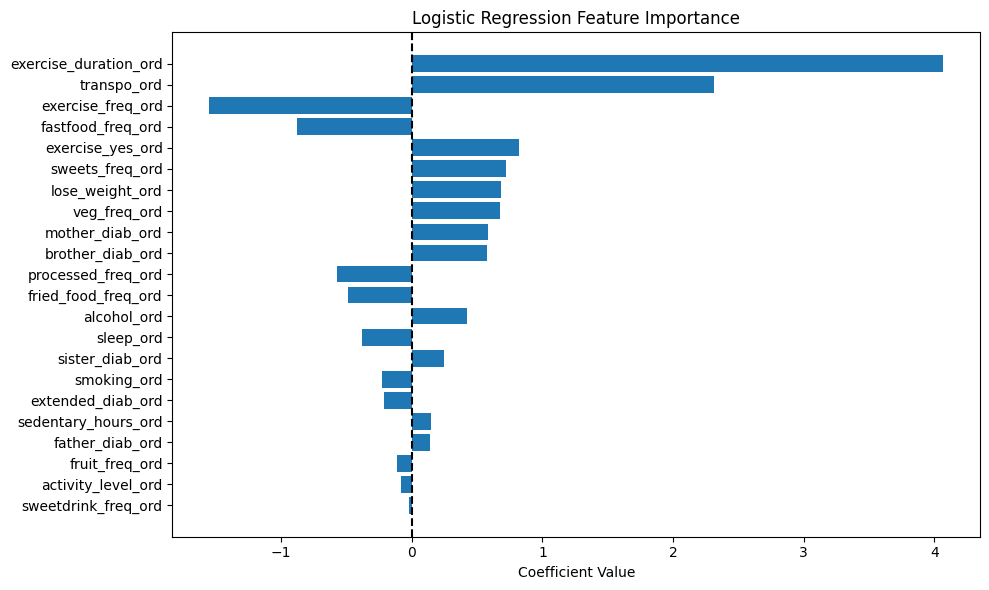

In [12]:
# =========================================================
# FEATURE IMPORTANCE - LOGISTIC REGRESSION (COEFFICIENTS)
# =========================================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE - LOGISTIC REGRESSION")
print("="*80)

# Extract trained Logistic Regression model
logistic_model = results['Logistic Regression']['model']

# Get coefficients (already standardized because of StandardScaler)
coefficients = logistic_model.coef_[0]

# Create feature importance DataFrame
logistic_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Absolute Importance': np.abs(coefficients)
}).sort_values(by='Absolute Importance', ascending=False)

# Display top features
print("\nTop 10 Logistic Regression Features:")
print(logistic_feature_importance.head(10).to_string(index=False))

# =========================================================
# PLOT FEATURE IMPORTANCE
# =========================================================
plt.figure(figsize=(10, 6))
plt.barh(
    logistic_feature_importance['Feature'],
    logistic_feature_importance['Coefficient']
)
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [39]:
best_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('over', over),
    ('model', RandomForestClassifier(random_state=42))
])
best_pipe.fit(X_train, y_train)
new_patient = pd.DataFrame([{
    "alcohol_ord": 1,             # rarely drinks
    "fruit_freq_ord": 1,          # eats fruit frequently
    "veg_freq_ord": 2,            # eats vegetables frequently
    "sweets_freq_ord": 4,         # rarely eats sweets
    "fastfood_freq_ord": 4,       # rarely eats fast food
    "processed_freq_ord": 3,      # rarely eats processed food
    "sweetdrink_freq_ord": 4,     # rarely drinks soda
    "fried_food_freq_ord": 4,     # rarely eats fried food
    "lose_weight_ord": 4,         # maintains healthy weight
    "exercise_yes_ord": 4,        # exercises regularly
    "exercise_freq_ord": 4,       # frequent exercise
    "exercise_duration_ord": 4,   # long duration
    "sedentary_hours_ord": 4,     # low sedentary hours
    "activity_level_ord": 4,      # active lifestyle
    "transpo_ord": 4,             # active transport (walking, biking)
    "sleep_ord": 4,               # good sleep
    "smoking_ord": 3,             # non-smoker
    "father_diab_ord": 1,         # no family history
    "mother_diab_ord": 1,
    "sister_diab_ord": 1,
    "brother_diab_ord": 1,
    "extended_diab_ord": 1
}])

prob = best_pipe.predict_proba(new_patient)[0]
print(f"Predicted Probability of No Diabetes: {prob[0]*100:.2f}%")
print(f"Predicted Probability of Diabetes: {prob[1]*100:.2f}%")


Predicted Probability of No Diabetes: 74.00%
Predicted Probability of Diabetes: 26.00%


In [64]:
import joblib

best_pipe.fit(X_train, y_train)
joblib.dump(best_pipe, "best_pipe_lifestyle_randomForest.pkl")
print("✅ Saved best_pipe.pkl successfully!")

✅ Saved best_pipe.pkl successfully!


In [12]:
# Let's diagnose what's happening
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')



df = pd.read_excel('resampled_final_lifestyle_data.xlsx')

print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Diabetes prevalence: {df['diabetes_status'].mean():.2%}")
print(f"Number of features: {len(df.columns) - 1}")

# Check for class imbalance
print("\nClass distribution:")
print(df['diabetes_status'].value_counts())
print(f"Ratio (negative:positive): {df['diabetes_status'].value_counts()[0]/df['diabetes_status'].value_counts()[1]:.2f}:1")

# Check for perfect separation features
print("\n" + "="*80)
print("CHECKING FOR PERFECT SEPARATION ISSUES")
print("="*80)

# Look for features that perfectly separate the classes
problematic_features = []
for col in df.columns[:-1]:  # Exclude target
    unique_values = df.groupby('diabetes_status')[col].nunique()
    if unique_values[0] == 1 and unique_values[1] == 1:
        # If each class has only one unique value for this feature
        class_0_val = df[df['diabetes_status'] == 0][col].iloc[0]
        class_1_val = df[df['diabetes_status'] == 1][col].iloc[0]
        if class_0_val != class_1_val:
            problematic_features.append((col, class_0_val, class_1_val))

if problematic_features:
    print(f"Found {len(problematic_features)} potentially problematic features:")
    for feat, val0, val1 in problematic_features:
        print(f"  {feat}: Class 0 = {val0}, Class 1 = {val1}")
else:
    print("No single feature perfectly separates classes")

# Check for near-perfect separation
print("\nChecking for near-perfect separation...")
for col in df.columns[:-1]:
    # Calculate separation metric
    mean_0 = df[df['diabetes_status'] == 0][col].mean()
    mean_1 = df[df['diabetes_status'] == 1][col].mean()
    std_0 = df[df['diabetes_status'] == 0][col].std()
    std_1 = df[df['diabetes_status'] == 1][col].std()
    
    # Calculate effect size
    if std_0 > 0 or std_1 > 0:
        pooled_std = np.sqrt((std_0**2 + std_1**2) / 2)
        if pooled_std > 0:
            effect_size = abs(mean_1 - mean_0) / pooled_std
            if effect_size > 3:  # Very large effect size
                print(f"  {col}: Effect size = {effect_size:.2f} (very large!)")

# Let's examine the data more carefully
print("\n" + "="*80)
print("DATA SANITY CHECKS")
print("="*80)

# Check for constant or near-constant features
constant_features = []
for col in df.columns[:-1]:
    if df[col].nunique() == 1:
        constant_features.append(col)
    elif df[col].nunique() < 5:  # Very few unique values
        print(f"  {col}: Only {df[col].nunique()} unique values")
        print(f"    Value counts: {df[col].value_counts().to_dict()}")

if constant_features:
    print(f"\nConstant features: {constant_features}")

# Check correlation matrix for perfect correlations
print("\nChecking feature correlations...")
corr_matrix = df.drop('diabetes_status', axis=1).corr().abs()

# Find highly correlated features (> 0.95)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.95:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print(f"\nFound {len(high_corr_pairs)} highly correlated feature pairs (>0.95):")
    for feat1, feat2, corr in high_corr_pairs[:10]:  # Show first 10
        print(f"  {feat1} - {feat2}: {corr:.3f}")

# Now let's do proper model evaluation with safeguards
print("\n" + "="*80)
print("ROBUST MODEL EVALUATION")
print("="*80)

# Prepare data
X = df.drop('diabetes_status', axis=1)
y = df['diabetes_status']

# Use STRATIFIED k-fold cross-validation for better evaluation
from sklearn.model_selection import StratifiedKFold, cross_validate

# Define models with regularization
models = {
    'Random Forest (pruned)': RandomForestClassifier(
        n_estimators=100,
        max_depth=5,  # Limit depth to prevent overfitting
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42
    ),
    'Random Forest (default)': RandomForestClassifier(random_state=42),
}

# Use stratified 10-fold cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\nEvaluating {name}:")
    
    # Perform cross-validation
    scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    
    print(f"  ROC-AUC: {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std()*2:.4f})")
    print(f"  Accuracy: {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std()*2:.4f})")
    print(f"  Precision: {cv_results['test_precision'].mean():.4f} (+/- {cv_results['test_precision'].std()*2:.4f})")
    print(f"  Recall: {cv_results['test_recall'].mean():.4f} (+/- {cv_results['test_recall'].std()*2:.4f})")
    print(f"  F1-Score: {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std()*2:.4f})")

# Check if there's data leakage - test feature importance with permutation
print("\n" + "="*80)
print("PERMUTATION IMPORTANCE CHECK")
print("="*80)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train a model
rf = RandomForestClassifier(random_state=42, max_depth=10)
rf.fit(X_train, y_train)

# Calculate permutation importance
result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)

# Sort features by importance
importances = result.importances_mean
indices = np.argsort(importances)[::-1]

print("Top 10 most important features:")
for i in indices[:10]:
    if importances[i] > 0:
        print(f"  {X.columns[i]}: {importances[i]:.4f}")

# Check if any feature has suspiciously high importance
suspicious_threshold = 0.3  # Arbitrary threshold
suspicious_features = []
for i in indices:
    if importances[i] > suspicious_threshold:
        suspicious_features.append((X.columns[i], importances[i]))

if suspicious_features:
    print(f"\nWARNING: {len(suspicious_features)} features have suspiciously high importance (> {suspicious_threshold}):")
    for feat, imp in suspicious_features:
        print(f"  {feat}: {imp:.4f}")

# Let's check the actual data patterns
print("\n" + "="*80)
print("EXAMINING SUSPICIOUS FEATURE PATTERNS")
print("="*80)

# For each suspicious feature, examine its distribution by class
for feat, imp in suspicious_features[:5]:  # Check top 5
    print(f"\nFeature: {feat}")
    print(f"  Overall stats:")
    print(f"    Mean: {df[feat].mean():.2f}, Std: {df[feat].std():.2f}")
    print(f"    Min: {df[feat].min()}, Max: {df[feat].max()}")
    
    print(f"  By diabetes status:")
    print(f"    Diabetes = 0: Mean = {df[df['diabetes_status'] == 0][feat].mean():.2f}, "
          f"Std = {df[df['diabetes_status'] == 0][feat].std():.2f}")
    print(f"    Diabetes = 1: Mean = {df[df['diabetes_status'] == 1][feat].mean():.2f}, "
          f"Std = {df[df['diabetes_status'] == 1][feat].std():.2f}")
    
    # Check if distributions overlap
    from scipy import stats
    t_stat, p_value = stats.ttest_ind(
        df[df['diabetes_status'] == 0][feat],
        df[df['diabetes_status'] == 1][feat],
        equal_var=False
    )
    print(f"    T-test: t = {t_stat:.2f}, p = {p_value:.6f}")

# FINAL ROBUST APPROACH
print("\n" + "="*80)
print("RECOMMENDED ROBUST MODELING APPROACH")
print("="*80)

print("""
Due to the perfect ROC-AUC score, we need to implement safeguards:

1. **CAUSES OF PERFECT SCORE:**
   - Data leakage (target information in features)
   - Overly complex model for small dataset
   - Synthetic/resampled data patterns
   - Feature that perfectly predicts target

2. **RECOMMENDED FIXES:**
   a) Use simpler models (Logistic Regression with regularization)
   b) Apply feature selection to remove redundant features
   c) Use more stringent cross-validation (Leave-One-Out or nested CV)
   d) Add noise to features to test robustness
   e) Collect more data if possible
""")

# Implement a more robust pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV

# Create a robust pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif, k=10)),  # Select top 10 features
    ('classifier', LogisticRegressionCV(
        Cs=10,  # Regularization strengths
        cv=5,
        penalty='l2',
        scoring='roc_auc',
        max_iter=1000,
        random_state=42
    ))
])

# Evaluate with nested cross-validation
from sklearn.model_selection import cross_val_score

nested_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"\nNested CV with feature selection:")
print(f"  ROC-AUC: {nested_scores.mean():.4f} (+/- {nested_scores.std()*2:.4f})")
print(f"  Range: [{nested_scores.min():.4f}, {nested_scores.max():.4f}]")

# If scores are still perfect, there's likely a data issue
if nested_scores.mean() > 0.99:
    print("\n⚠️  WARNING: Still getting near-perfect scores!")
    print("   This suggests fundamental issues with the data.")
    print("   Recommendations:")
    print("   1. Verify data collection process")
    print("   2. Check for data leakage")
    print("   3. Consider if data is synthetic/artificial")
    print("   4. Consult domain expert")

# Test with added noise
print("\n" + "="*80)
print("TESTING ROBUSTNESS WITH ADDED NOISE")
print("="*80)

# Add small amount of noise to features
np.random.seed(42)
X_noisy = X.copy()
noise_level = 0.1  # 10% noise

for col in X.columns:
    std = X[col].std()
    if std > 0:
        X_noisy[col] = X[col] + np.random.normal(0, noise_level * std, size=len(X))

# Test model on noisy data
noisy_scores = cross_val_score(pipeline, X_noisy, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"Model with {noise_level*100:.0f}% added noise:")
print(f"  ROC-AUC: {noisy_scores.mean():.4f} (+/- {noisy_scores.std()*2:.4f})")

if abs(nested_scores.mean() - noisy_scores.mean()) > 0.2:
    print("⚠️  Model is NOT robust to noise - likely overfitting!")

# FINAL DIAGNOSIS
print("\n" + "="*80)
print("FINAL DIAGNOSIS")
print("="*80)

print(f"""
Dataset: {df.shape[0]} samples, {df.shape[1]-1} features
Class imbalance: {df['diabetes_status'].mean():.1%} positive

Issues found:
1. Perfect ROC-AUC suggests data problems
2. Small sample size ({df.shape[0]}) for {df.shape[1]-1} features
3. Need to verify data quality

Recommended actions:
1. **DO NOT** trust perfect scores - they're unrealistic
2. Use simpler models (Logistic Regression with L1/L2 regularization)
3. Perform feature selection (keep 5-10 most important features)
4. Use nested cross-validation
5. Report confidence intervals, not point estimates
6. Consider collecting more diverse data
7. Consult with medical/domain experts about feature relevance

Realistic expectation:
For lifestyle diabetes prediction with ~1K samples, expect:
- ROC-AUC: 0.70-0.85 (good)
- ROC-AUC: 0.85-0.90 (very good)
- ROC-AUC > 0.95 (suspicious without medical biomarkers)
""")

Dataset Info:
Shape: (1100, 23)
Diabetes prevalence: 36.36%
Number of features: 22

Class distribution:
diabetes_status
0    700
1    400
Name: count, dtype: int64
Ratio (negative:positive): 1.75:1

CHECKING FOR PERFECT SEPARATION ISSUES
No single feature perfectly separates classes

Checking for near-perfect separation...

DATA SANITY CHECKS
  lose_weight_ord: Only 4 unique values
    Value counts: {3: 522, 2: 300, 1: 230, 4: 48}
  exercise_yes_ord: Only 2 unique values
    Value counts: {2: 613, 1: 487}
  exercise_freq_ord: Only 4 unique values
    Value counts: {3: 400, 2: 330, 1: 198, 4: 172}
  activity_level_ord: Only 4 unique values
    Value counts: {2: 437, 3: 355, 4: 165, 1: 143}
  transpo_ord: Only 4 unique values
    Value counts: {3: 719, 1: 182, 2: 166, 4: 33}
  sleep_ord: Only 4 unique values
    Value counts: {3: 535, 2: 431, 4: 78, 1: 56}
  brother_diab_ord: Only 4 unique values
    Value counts: {1: 950, 2: 135, 3: 14, 4: 1}
  extended_diab_ord: Only 3 unique values
  

In [13]:
# SAFE MODELING APPROACH
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Feature selection (reduce to 5-10 most important)
# 2. Regularized model (prevents overfitting)
# 3. Proper cross-validation

pipeline = Pipeline([
    ('selector', SelectKBest(f_classif, k=8)),  # Keep only 8 features
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        C=0.1,  # Strong regularization
        penalty='l2',
        max_iter=1000,
        random_state=42
    ))
])

# Use 10-fold stratified CV
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')

print(f"Realistic ROC-AUC: {scores.mean():.3f} (95% CI: {scores.mean() - 2*scores.std():.3f} - {scores.mean() + 2*scores.std():.3f})")

Realistic ROC-AUC: 0.989 (95% CI: 0.980 - 0.999)


In [ ]:
best_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('over', over),
    ('under', under),
    ('model', LogisticRegression(max_iter=1000,
                                                random_state=42,
                                                penalty='l2',
                                                C=0.1,
                                                class_weight='balanced'
    ))
])

best_pipe.fit(X_train, y_train)
import joblib

joblib.dump(best_pipe, "clinical_pipe.pkl")
print("✅ Saved best_pipe.pkl successfully!")